# Retrieval-Augmented Generation for Legal Cases


## 1. Configuration / Parameters


In [0]:
%pip install --upgrade 'datasets>=3.0.0' 'huggingface-hub>=0.26.0' 'fsspec>=2024.2.0' databricks-langchain faiss-cpu rouge-score langchain-community langchain-text-splitters mlflow transformers peft accelerate sentencepiece scikit-learn torch --quiet
dbutils.library.restartPython()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 1.1.6 requires openai<3.0.0,>=1.109.1, but you have openai 3.8.0 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# ---------- Most likely to be changed by an evaluator ----------
dbutils.widgets.text("INPUT_QUESTION", "In the case involving Isaac J. Lewis of Nevada, Harris Lewis of California, and an alleged partnership between them, why did the Supreme Court hold that the suit was not removable to federal court?", "Input Question")

dbutils.widgets.text("TOP_K", "3", "Top K")
dbutils.widgets.text("EMBEDDING_ENDPOINT", "databricks-bge-large-en", "Embedding Endpoint")
dbutils.widgets.text("LLM_ENDPOINT", "databricks-meta-llama-3-1-8b-instruct", "LLM Endpoint")
dbutils.widgets.text("TEMPERATURE", "0.1", "Temperature")
dbutils.widgets.text("SUMMARY_CASE_ID", "51", "Summary Case ID")  # which case is evaluated against its ground-truth syllabus
dbutils.widgets.text("SUMMARY_INPUT_QUESTION", "Summarize the case involving Isaac J. Lewis and Harris Lewis, focusing on the partnership dispute and the court’s decision on removal to federal court.", "Summary Input Question")  # which case is evaluated against its ground-truth syllabus

INPUT_QUESTION = dbutils.widgets.get("INPUT_QUESTION")
TOP_K = int(dbutils.widgets.get("TOP_K"))
EMBEDDING_ENDPOINT = dbutils.widgets.get("EMBEDDING_ENDPOINT")
LLM_ENDPOINT = dbutils.widgets.get("LLM_ENDPOINT")
TEMPERATURE = float(dbutils.widgets.get("TEMPERATURE"))
SUMMARY_CASE_ID = int(dbutils.widgets.get("SUMMARY_CASE_ID"))
SUMMARY_INPUT_QUESTION = dbutils.widgets.get("SUMMARY_INPUT_QUESTION")

In [0]:
# ---------- Pipeline parameters ----------
CHUNK_SIZE = 800
CHUNK_OVERLAP = 150

MAX_TOKENS = 900
SAMPLE_SIZE = 150

# ---------- Practical settings ----------
NUM_CASES = 5             # CaseSumm has ~27k opinions; a small sample keeps the notebook runnable
SUMMARY_TOP_K = 8         # summarization needs more context than a single-fact question
EMBED_BATCH_SIZE = 16     # chunks sent per call to the embedding endpoint
FAISS_INDEX_PATH = "/tmp/casesumm_faiss_index"

CATALOG = "workspace"
SCHEMA = "legal"
CASES_TABLE = f"{CATALOG}.{SCHEMA}.cases"
CHUNKS_TABLE = f"{CATALOG}.{SCHEMA}.case_chunks"

# FAISS index locations. Build locally, then copy to the volume so it survives cluster restarts.
VOLUME = "artifacts"
FAISS_INDEX_PATH = "/tmp/casesumm_faiss_index"                                  # local working copy
FAISS_VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}/casesumm_faiss_index"  # persistent copy

HYBRID_INDEX_PATH = "/tmp/hybrid_faiss_index"                                  # local working copy
HYBRID_VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}/hybrid_faiss_index"  # persistent copy

print("Config loaded")
print(f"  cases table      : {CASES_TABLE}")
print(f"  embedding model  : {EMBEDDING_ENDPOINT}")
print(f"  llm              : {LLM_ENDPOINT}")
print(f"  chunking         : size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP}")
print(f"  top_k            : {TOP_K}")

Config loaded
  cases table      : workspace.legal.cases
  embedding model  : databricks-bge-large-en
  llm              : databricks-meta-llama-3-1-8b-instruct
  chunking         : size=800, overlap=150
  top_k            : 3


## 2. Environment Setup

In [0]:
from itertools import islice

import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from databricks_langchain import DatabricksEmbeddings, ChatDatabricks
from rouge_score import rouge_scorer
import os
import shutil

print("Libraries imported")

Libraries imported


## 3. Load CaseSumm Dataset


In [0]:
# Hugginface token
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
dataset = load_dataset("ChicagoHAI/CaseSumm", split="train")

print("Records loaded :", len(dataset))
print("Columns        :", list(dataset.column_names))

# Convert to pandas for easier manipulation
df = dataset.to_pandas()

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:56: UserWarning: The cache_dir for this dataset is /tmp/.hf.data.cache, which is not a persistent path.Therefore, if/when the cluster restarts, the downloaded dataset will be lost.The persistent storage options for this workspace/cluster config are: [UC Volumes].Please update either `cache_dir` or the environment variable `HF_DATASETS_CACHE`to be under one of the following root directories: ['/Volumes/']
  warnings.warn(warning_message)


README.md:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:24: UserWarning: During large dataset downloads, there could be multiple progress bar widgets that can cause performance issues for your notebook or browser. To avoid these issues, use `datasets.utils.logging.disable_progress_bar()` to turn off the progress bars.
  warnings.warn(


data-00000-of-00002.arrow: reconstructing file:   0%|          |  0.00B /  243MB            

data-00000-of-00002.arrow: downloading bytes:           |  0.00B            

data-00001-of-00002.arrow: reconstructing file:   0%|          |  0.00B /  261MB            

data-00001-of-00002.arrow: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/27071 [00:00<?, ? examples/s]

Records loaded : 27071
Columns        : ['citation', 'syllabus', 'opinion']


In [0]:
# Rename columns to standard names
df = df.rename(columns={
    'opinion': 'text',
    'syllabus': 'summary'
})

# Keep only the text and summary columns
df = df[['text', 'summary']]

print(f"Data quality checks:")
print(f"  - Null text values: {df['text'].isna().sum()}")
print(f"  - Null summary values: {df['summary'].isna().sum()}")
print(f"  - Empty text values: {(df['text'].str.strip() == '').sum()}")
print(f"  - Empty summary values: {(df['summary'].str.strip() == '').sum()}")

# Remove any rows with null or empty values
original_count = len(df)
df = df.dropna()
df = df[(df['text'].str.strip() != '') & (df['summary'].str.strip() != '')]
print(f"  - Records after cleaning: {len(df)} (removed {original_count - len(df)})")

# Display sample records
print("\nSample record:")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")
print(f"\nSummary (first 300 chars): {df.iloc[0]['summary'][:300]}...")

Data quality checks:
  - Null text values: 0
  - Null summary values: 0
  - Empty text values: 1
  - Empty summary values: 0
  - Records after cleaning: 27070 (removed 1)

Sample record:
Text (first 500 chars): This motion to dismiss is made because, as is alleged, (1) the decree appealed from is not a final decree; and (2) the transcript is not properly certified. 1. As to the decree. The case is in some particulars different from that of the St. Louis, I. M. & S. Ry. Co. v. Southern Express Co., just decided,   but in our opinion the differences do not materially affect the present question.* Ante, 6. The decree in this case, as in that, requires the railway company to carry for the express company, ...

Summary (first 300 chars): 1. On the merits of the motion there is no essential difference between this case and the case of the St. Louis, Iron 3lountain and Southern R. R. Co. v. The Southern IExpress Company, just decided. Reference to the master to take and state an account betwe

## 4. Save Dataset to Unity Catalog

The cleaned cases are written to the Delta table `workspace.legal.cases`. The required columns are
`text` (the opinion) and `summary` (the ground-truth syllabus).

In [0]:
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")

if not spark.catalog.tableExists(CASES_TABLE):
    (
        spark.createDataFrame(df)
        .write.mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(CASES_TABLE)
    )

print("Saved:", CASES_TABLE)
spark.table(CASES_TABLE).printSchema()

Saved: workspace.legal.cases
root
 |-- text: string (nullable = true)
 |-- summary: string (nullable = true)



In [0]:
# Read the table and show a few records from the Delta table

table_name = f"{CATALOG}.{SCHEMA}.cases"

verify_df = spark.table(table_name)
print(f"  - Table: {table_name}")
print(f"  - Record count: {verify_df.count()}")
print(f"  - Columns: {verify_df.columns}")

# Display sample records from Delta table
print("\nSample records from Delta table:")
display(verify_df.limit(3))

  - Table: workspace.legal.cases
  - Record count: 27070
  - Columns: ['text', 'summary']

Sample records from Delta table:


text summary These three appeals were restored to the calendar for reargument. 392 U.S. 920, 88 S.Ct. 2272, 20 L.Ed.2d 1381 (1968). Each is an appeal from a decision of a three-judge District Court holding unconstitutional a State or District of Columbia statutory provision which denies welfare assistance to residents of the State or District who have not resided within their jurisdictions for at least one year immediately preceding their applications for such assistance.1 We affirm the judgments of the District Courts in the three cases. In No. 9, the Connecticut Welfare Department invoked § 17—2d of the Connecticut General Statutes2 to deny the application of appellee Vivian Marie Thompson for assistance under the program for Aid to Families with Dependent Children (AFDC). She was a 19-year-old unwed mother of one child and pregnant with her second child when she changed her residence in June 1966 from Dorchester, Massachusetts, to Hartford, Connecticut, to live with her mother, a Hartford resident. She moved to her own apartment in Hartford in August 1966, when her mother was no longer able to support her and her infant son. Because of her pregnancy, she was unable to work or enter a work training program. Her application for AFDC assistance, filed in August, was denied in November solely on the ground that, as required by § 17—2d, she had not lived in the State for a year before her application was filed. She brought this action in the District Court for the District of Connecticut where a three-judge court, one judge dissenting, declared § 17—2d unconstitutional. 270 F.Supp. 331 (1967). The majority held that the waiting-period requirement is unconstitutional because it 'has a chilling effect on the right to travel.' Id., at 336. The majority also held that the provision was a violation of the Equal Protection Clause of the Fourteenth Amendment because the denial of relief to those resident in the State for less than a year is not based on any permissible purpose but is solely designed as 'Connecticut states quite frankly,' 'to protect its fisc by discouraging entry of those who come needing relief.' Id., at 336—337. We noted probable jurisdiction. 389 U.S. 1032, 88 S.Ct. 784, 19 L.Ed.2d 820 (1968). In No. 33, there are four appellees. Three of them—appellees Harrell, Brown, and Legrant—applied for and were denied AFDC aid. The fourth, appellee Barley, applied for and was denied benefits under the program for Aid to the Permanently and Totally Disabled. The denial in each case was on the ground that the applicant had not resided in the District of Columbia for one year immediately preceding the filing of her application, as required by § 3—203 of the District of Columbia Code.3 Appellee Minnie Harrell, now deceased, had moved with her three children from New York to Washington in September 1966. She suffered from cancer and moved to be near members of her family who lived in Washington. Appellee Barley, a former resident of the District of Columbia, returned to the District in March 1941 and was committed a month later to St. Elizabeths Hospital as mentally ill. She has remained in that hospital ever since. She was deemed eligible for release in 1965, and a plan was made to transfer her from the hospital to a foster home. The plan depended, however, upon Mrs. Barley's obtaining welfare assistance for her support. Her application for assistance under the program for Aid to the Permanently and Totally Disabled was denied because her time spent in the hospital did not count in determining compliance with the one-year requirement. Appellee Brown lived with her mother and two of her three children in Fort Smith, Arkansas. Her third child was living with appellee Brown's father in the District of Columbia. When her mother moved from Fort Smith of Oklahoma, appellee Brown, in February 1966, returned to the District of Columbia where she lived as a child. Her application for AFDC assistance was approved insofar as it sought assis

## 5. Document Chunking

**Why chunking is needed:** a single Supreme Court opinion runs to tens of thousands of characters -
far beyond an embedding model's input limit and wasteful to feed to an LLM in full. Splitting the
opinion into small passages lets the retriever pull back only the few paragraphs that actually
relate to the question. The 150-character overlap keeps a sentence that straddles a boundary from
losing its context.

In [0]:
# Read the table back - everything downstream works from the Delta table, not the raw download
cases_df = spark.table(CASES_TABLE).toPandas()
print("Rows read back from Delta:", len(cases_df))

# Use sample of the dataset if configured
sample_cases_df = df.head(SAMPLE_SIZE) if SAMPLE_SIZE else df
print(f"Processing {len(sample_cases_df)} cases (SAMPLE_SIZE={SAMPLE_SIZE})")

print("Chunking legal case opinions...")
print(f"Parameters: chunk_size={CHUNK_SIZE}, chunk_overlap={CHUNK_OVERLAP}")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""],  # prefer paragraph, then sentence boundaries
)

# Split every opinion and keep track of which case each chunk came from
chunk_rows = []
for case_id, case in sample_cases_df.iterrows():
    for chunk_id, chunk_text in enumerate(splitter.split_text(case["text"])):
        chunk_rows.append(
            {"case_id": case_id, "chunk_id": chunk_id, "text": chunk_text, "summary": case["summary"]}
        )

chunks_df = pd.DataFrame(chunk_rows)

print("Cases              :", chunks_df["case_id"].nunique())
print("Total chunks       :", len(chunks_df))

print("\n----- EXAMPLE CHUNK -----")
example = chunks_df.iloc[0]
print(f"case_id={example['case_id']}  chunk_id={example['chunk_id']}  length={len(example['text'])}\n")
print(example["text"])

Rows read back from Delta: 27070
Processing 150 cases (SAMPLE_SIZE=150)
Chunking legal case opinions...
Parameters: chunk_size=800, chunk_overlap=150
Cases              : 150
Total chunks       : 3736

----- EXAMPLE CHUNK -----
case_id=0  chunk_id=0  length=398

This motion to dismiss is made because, as is alleged, (1) the decree appealed from is not a final decree; and (2) the transcript is not properly certified. 1. As to the decree. The case is in some particulars different from that of the St. Louis, I. M. & S. Ry. Co. v. Southern Express Co., just decided,   but in our opinion the differences do not materially affect the present question.* Ante, 6


In [0]:
# Persist the chunks so they can be inspected / reused without re-splitting
if not spark.catalog.tableExists(CHUNKS_TABLE):
    (
        spark.createDataFrame(chunks_df)
        .write.mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(CHUNKS_TABLE)
    )
    print("Saved:", CHUNKS_TABLE)
else:
    print("Table already exists:", CHUNKS_TABLE)

display(spark.sql(f"SELECT * FROM {CHUNKS_TABLE} ORDER BY case_id, chunk_id LIMIT 5"))

Table already exists: workspace.legal.case_chunks


case_id,chunk_id,text,summary
0,0,"This motion to dismiss is made because, as is alleged, (1) the decree appealed from is not a final decree; and (2) the transcript is not properly certified. 1. As to the decree. The case is in some particulars different from that of the St. Louis, I. M. & S. Ry. Co. v. Southern Express Co., just decided, but in our opinion the differences do not materially affect the present question.* Ante, 6","1. On the merits of the motion there is no essential difference between this case and the case of the St. Louis, Iron 3lountain and Southern R. R. Co. v. The Southern IExpress Company, just decided. Reference to the master to take and state an account between the parties as to the compensation during the litigation and up to its final termination relates to matters of administration not involving the merits. 2. A certificate that the transcript is a ""' true, full and perfect copy from the record of all the proceedings in the suit"" is sufficient to give jurisdiction. 3. If the certificate is not correct, the remedy is by certiorari. 4. Where on the face of the decree it appears that a case was disposed of on demurrer to the bill, the evidence on Me is not necessary for the hearing of the bill. 5. When a record has not been printed, and parties do not agree as to its contents, certiorari may be granted, reserving all questions till return."
0,1,". M. & S. Ry. Co. v. Southern Express Co., just decided, but in our opinion the differences do not materially affect the present question.* Ante, 6. The decree in this case, as in that, requires the railway company to carry for the express company, and fixes the rate of compensation, 'until the further order or decree of this [circuit] court.' In this case, the reference to the master 'to take and state an account between the parties as to the compensation that should be and has been paid during the litigation, and up to the final termination thereof,' was entered before or at the time of the decree from which the appeal was taken. Still, in this, as in that, the reference is in respect to matters affecting the administration of the cause, and does not involve the merits","1. On the merits of the motion there is no essential difference between this case and the case of the St. Louis, Iron 3lountain and Southern R. R. Co. v. The Southern IExpress Company, just decided. Reference to the master to take and state an account between the parties as to the compensation during the litigation and up to its final termination relates to matters of administration not involving the merits. 2. A certificate that the transcript is a ""' true, full and perfect copy from the record of all the proceedings in the suit"" is sufficient to give jurisdiction. 3. If the certificate is not correct, the remedy is by certiorari. 4. Where on the face of the decree it appears that a case was disposed of on demurrer to the bill, the evidence on Me is not necessary for the hearing of the bill. 5. When a record has not been printed, and parties do not agree as to its contents, certiorari may be granted, reserving all questions till return."
0,2,". Still, in this, as in that, the reference is in respect to matters affecting the administration of the cause, and does not involve the merits. The reservation of power to change the rates operates only on the future, and was evidently intended for the purpose of enabling the court to act in case a change should be required. As the decree stands, the express company can require the railway company to carry at the rate which has been fixed. 2. As to the certificate. The clerk certifies the transcript sent up to be 'a true, full, and perfect copy from the record of all the proceedings in the suit.' Certainly this is sufficient for all the purposes of jurisdiction","1. On the merits of the motion there is no essential difference between this case and the case of the St. Louis, Iron 3lountain and Southern R. R. Co. v. The Southern IExpress Company, just

## 6. Generate Embeddings & Build FAISS Vector Store

Embeddings turn each chunk of legal text into a numeric vector. Chunks that mean similar things end
up close together in that vector space, which is what lets us retrieve passages by *meaning* rather
than by keyword match.

Chunks are sent to the Databricks `bge-large-en` endpoint in batches rather than one at a time.

In [0]:
embeddings = DatabricksEmbeddings(endpoint=EMBEDDING_ENDPOINT)

# Reuse the saved index if one exists - embedding 3,736 chunks takes several minutes
index_exists = os.path.exists(f"{FAISS_VOLUME_PATH}/index.faiss")

chunks_df = spark.table(CHUNKS_TABLE).toPandas()

chunk_texts = chunks_df["text"].tolist()
chunk_vectors = []

# Batch the requests to the serving endpoint
for start in range(0, len(chunk_texts), EMBED_BATCH_SIZE):
    batch = chunk_texts[start : start + EMBED_BATCH_SIZE]
    chunk_vectors.extend(embeddings.embed_documents(batch))
    print(f"  embedded {len(chunk_vectors)}/{len(chunk_texts)} chunks", end="\r")

print(f"\nEmbeddings generated : {len(chunk_vectors)}")
print(f"Embedding dimension  : {len(chunk_vectors[0])}")
print(f"First 8 values       : {[round(v, 4) for v in chunk_vectors[0][:8]]}")


# Building FAISS Vector Store
# Pair each chunk with its pre-computed vector, plus metadata for traceability
text_embedding_pairs = list(zip(chunk_texts, chunk_vectors))

metadatas = [
    {"case_id": int(row.case_id), "chunk_id": int(row.chunk_id)}
    for row in chunks_df.itertuples()
]

vector_store = FAISS.from_embeddings(
    text_embeddings=text_embedding_pairs,
    embedding=embeddings,          # used to embed queries at search time
    metadatas=metadatas,
)

# Save locally first - volumes don't support the random writes some libraries use
vector_store.save_local(FAISS_INDEX_PATH)

# Then copy to the Unity Catalog volume so the index outlives the cluster
spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME}")
shutil.copytree(FAISS_INDEX_PATH, FAISS_VOLUME_PATH, dirs_exist_ok=True)

vector_store = FAISS.load_local(
        FAISS_VOLUME_PATH, embeddings, allow_dangerous_deserialization=True
)
print(f"Loaded {vector_store.index.ntotal} vectors from the volume")

print("Vectors in FAISS index:", vector_store.index.ntotal)
print("Local copy            :", FAISS_INDEX_PATH)
print("Persisted to          :", FAISS_VOLUME_PATH)

  embedded 3736/3736 chunks
Embeddings generated : 3736
Embedding dimension  : 1024
First 8 values       : [-0.0503, -0.019, -0.0175, 0.0695, -0.0479, -0.0096, -0.0408, -0.0174]
Loaded 3736 vectors from the volume
Vectors in FAISS index: 3736
Local copy            : /tmp/casesumm_faiss_index
Persisted to          : /Volumes/workspace/legal/artifacts/casesumm_faiss_index


## 7. Retrieval-Augmented Generation (RAG)

`retrieve_chunks(question, k)` embeds the question and returns the `k` most similar chunks.

### 7.1 Single-Fact Question Retrieval

In [0]:
def retrieve_chunks(question, k):
    """Return the k most semantically similar chunks, optionally limited to one case."""
    return vector_store.similarity_search(question, k=k)

def show_chunks(docs):
    """Print retrieved chunks so an evaluator can verify retrieval actually happened."""
    for i, doc in enumerate(docs, start=1):
        print(f"--- Chunk {i} | case_id={doc.metadata['case_id']} | chunk_id={doc.metadata['chunk_id']} ---")
        print(doc.page_content)
        print()


### 7.2 Generate Answer with LLM

A single chat model plus one prompt template. The prompt tells the model to answer strictly from the
retrieved context and to say so when the context is insufficient, which is the main guard against
hallucinated legal facts.

In [0]:
llm = ChatDatabricks(endpoint=LLM_ENDPOINT, temperature=TEMPERATURE)

PROMPT_TEMPLATE = """You are a legal research assistant.

Answer the user's question using only the legal context provided below.

Rules:
- Use only facts that appear in the context. Do not add outside legal knowledge.
- Do not invent facts, dates, statutes, holdings, or legal conclusions.
- If the context does not contain enough information, say so.
- Keep factual answers concise and direct.

If the user asks to summarize the case:
- Write a concise legal case summary in the style of a legal syllabus.
- Write in continuous legal prose, not bullet points, numbered lists, headings,
  or labeled sections.
- Begin with the main decision or holding when possible.
- Cover the key legal issue(s), applicable legal rule(s), and main reasoning.
- Include important facts, exceptions, statutes, dates, or amounts when relevant.
- Use appropriate legal terms to refer to people and parties, such as
  "the plaintiff", "the defendant", "the appellant", "the appellee",
  "the petitioner", "the respondent", "the accused", or the relevant
  legal role or entity.
- Do not mention personal names or case names.
- Prefer legal roles and descriptions over party names when the identity
  of the person is not legally important.
- Focus on the legally significant points rather than retelling the entire case.
- Do not simply copy the retrieved context.

If the user asks a specific factual question:
- Answer only what was asked.
- Do not provide a full case summary unless requested.

Context:
{context}

Question:
{question}

Answer:"""

# Smoke test that the endpoint is reachable
print(llm.invoke("Reply with the single word: ready").content)

Ready


`generate_answer` ties the pieces together: retrieve → build context → prompt → LLM → answer.

In [0]:
def format_context(docs):
    """Join retrieved chunks into a single context block, labelled for traceability."""
    return "\n\n---\n\n".join(
        f"[case {d.metadata['case_id']} | chunk {d.metadata['chunk_id']}]\n{d.page_content}"
        for d in docs
    )

def generate_answer(question, k):
    """Run the full RAG pipeline and return (answer, retrieved_docs)."""
    docs = retrieve_chunks(question, k)
    prompt = PROMPT_TEMPLATE.format(context=format_context(docs), question=question.strip())
    answer = llm.invoke(prompt).content
    return answer, docs

In [0]:
answer, retrieved_docs = generate_answer(INPUT_QUESTION, TOP_K)

print("=" * 90)
print("INPUT QUESTION")
print("=" * 90)
print(INPUT_QUESTION.strip())

print("\n" + "=" * 90)
print(f"RETRIEVED CONTEXT (top {TOP_K})")
print("=" * 90)
show_chunks(retrieved_docs)

print("=" * 90)
print("GENERATED ANSWER")
print("=" * 90)
print(answer)

INPUT QUESTION
In the case involving Isaac J. Lewis of Nevada, Harris Lewis of California, and an alleged partnership between them, why did the Supreme Court hold that the suit was not removable to federal court?

RETRIEVED CONTEXT (top 3)
--- Chunk 1 | case_id=51 | chunk_id=10 ---
. If there was no partnership, they all go free and each keeps the property he has got. If there was, the interests of these parties may become antagonistic. Besides, on the question of partnership, Harris Lewis, a citizen of California, is a necessary party. If he insists on the partnership, as he certainly may, then, in arranging the parties on that question, there will be citizens of Nevada and California on one side, and citizens of the same states on the other. Clearly, under these circumstances, the suit was not removable under the first clause of the second section of the act of March 3, 1875, c. 137. Neither was there any separable controversy in the suit such as would entitle any of the parties to a

## 8. Legal Case Summarization Evaluation

One case (`SUMMARY_CASE_ID`) is summarized by the RAG pipeline and compared against its official
syllabus. Retrieval is restricted to that case, and `SUMMARY_TOP_K` chunks are used because a
summary needs broader coverage than a single-fact question.

In [0]:
# Select the Case to summarize
selected_case = chunks_df[chunks_df["case_id"] == SUMMARY_CASE_ID]
ground_truth_summary = selected_case["summary"].iloc[0]

# print("\nSummary")
# print(ground_truth_summary)

# SUMMARY_QUESTION = """
# Summarize the case involving Isaac J. Lewis and Harris Lewis, focusing on the partnership dispute and the court’s decision on removal to federal court.
# """

generated_summary, summary_docs = generate_answer(
    SUMMARY_INPUT_QUESTION, TOP_K)

print(f"Opinion length {len(selected_case['text'])} chars "
      f"| chunks used {len(summary_docs)}")

print("\n" + "=" * 90)
print("GROUND TRUTH SYLLABUS")
print("=" * 90)
print(ground_truth_summary)

print("\n" + "=" * 90)
print("GENERATED RAG SUMMARY")
print("=" * 90)
print(generated_summary)

Opinion length 12 chars | chunks used 3

GROUND TRUTH SYLLABUS
1. When in the settlement of a controversy one of the plaintiffs and one of the defendants, necessary parties for the determination of the issues, are citizens of the same State, the cause cannot be removed from the State court under the first clause of section 2, of the act of March 3d, 1875, ch. 137, 18 Stat. 470. 2. In the present case the issue is not a separable controversy which, under the provisions of the second clause in that section, can be so removed.

GENERATED RAG SUMMARY
This appeal concerns a suit brought by Isaac J. Lewis, a citizen of Nevada, against Harris Lewis, a citizen of California, and other defendants, for the dissolution of an alleged partnership and a settlement of the partnership affairs. The court remanded the suit to the state court of Nevada, and this appeal was taken. The court held that the suit was not removable to federal court under the first clause of the second section of the Act of Mar

## 9. ROUGE Evaluation

ROUGE compares the generated summary against the ground-truth syllabus by n-gram overlap.

* **Precision** - how much of the generated text appears in the syllabus.
* **Recall** - how much of the syllabus is covered by the generated text.
* **F1** - the harmonic mean of the two.

### 9.1 Compute ROUGE Scores

In [0]:
ROUGE_TYPES = ["rouge1", "rouge2", "rougeL"]

scorer = rouge_scorer.RougeScorer(ROUGE_TYPES, use_stemmer=True)
scores = scorer.score(ground_truth_summary, generated_summary)

rouge_df = pd.DataFrame(
    [
        {
            "Metric": rouge_type,
            "Precision": round(scores[rouge_type].precision, 4),
            "Recall": round(scores[rouge_type].recall, 4),
            "F1": round(scores[rouge_type].fmeasure, 4),
        }
        for rouge_type in ROUGE_TYPES
    ]
)

display(rouge_df)

Metric,Precision,Recall,F1
rouge1,0.3,0.6279,0.406
rouge2,0.1397,0.2941,0.1894
rougeL,0.2056,0.4302,0.2782


### 9.2 Visualize Results

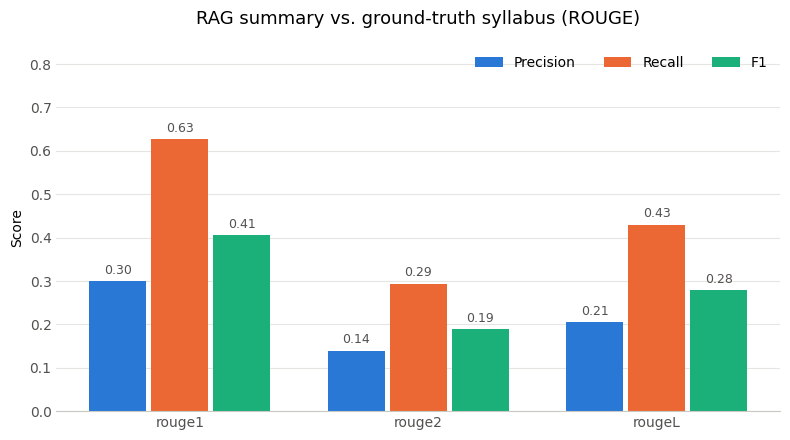

In [0]:
metrics = rouge_df["Metric"].tolist()
series = ["Precision", "Recall", "F1"]
colors = ["#2a78d6", "#eb6834", "#1baf7a"]

x = range(len(metrics))
width = 0.26

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (name, color) in enumerate(zip(series, colors)):
    offset = (i - 1) * width
    bars = ax.bar([pos + offset for pos in x], rouge_df[name], width * 0.92, label=name, color=color)
    # Direct value labels keep the chart readable without squinting at the axis
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color="#52514e")

ax.set_title("RAG summary vs. ground-truth syllabus (ROUGE)", fontsize=13, pad=14)
ax.set_ylabel("Score")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, min(1.0, max(rouge_df[series].max().max() * 1.35, 0.1)))
ax.legend(frameon=False, ncol=3, loc="upper right")

# Recessive grid and axes so the bars carry the message
ax.yaxis.grid(True, color="#e5e5e2", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c9c9c4")
ax.tick_params(length=0, colors="#52514e")

plt.tight_layout()
plt.show()

# Stretch Goal


## 1. Hybrid RAG - Multi-Source Indexing

### Why this financial dataset

**[`virattt/financial-qa-10K`](https://huggingface.co/datasets/virattt/financial-qa-10K)**

* Its `context` column is verbatim text from an **SEC Form 10-K** — a compliance document
  filed under the Securities Exchange Act, not commentary about one.
* It is stored as parquet with no loading script, so it works with `datasets>=3.0`. Larger
  SEC corpora such as EDGAR-CORPUS still ship loading scripts, which that version dropped.
* 7,000 rows is small enough to embed in a few minutes on Free Edition.

In [0]:
# dbutils.widgets.text("FIN_DOC_LIMIT", "400", "Financial docs to index")
FIN_DOC_LIMIT = 400

FIN_DATASET = "virattt/financial-qa-10K"
HYBRID_INDEX_PATH = "/tmp/hybrid_faiss_index"
HYBRID_CHUNKS_TABLE = f"{CATALOG}.{SCHEMA}.hybrid_chunks"

In [0]:
fin_raw = load_dataset(FIN_DATASET, split="train").to_pandas()
print(f"Loaded {len(fin_raw):,} rows | columns: {list(fin_raw.columns)}")

# The same passage backs several questions, so keep each passage once.
fin_docs = fin_raw[["context", "ticker"]].dropna()
fin_docs["context"] = fin_docs["context"].str.strip()
fin_docs = fin_docs[fin_docs["context"] != ""].drop_duplicates("context").reset_index(drop=True)
print(f"Unique contexts: {len(fin_docs):,}")

if FIN_DOC_LIMIT:
    fin_docs = fin_docs.head(FIN_DOC_LIMIT)
    print(f"Using {len(fin_docs):,} documents (FIN_DOC_LIMIT={FIN_DOC_LIMIT})")

# Give every financial document a readable ID for the retrieval output.
fin_docs["document_id"] = [f"10K-{i:04d}" for i in range(len(fin_docs))]
display(fin_docs.head(3))

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:56: UserWarning: The cache_dir for this dataset is /tmp/.hf.data.cache, which is not a persistent path.Therefore, if/when the cluster restarts, the downloaded dataset will be lost.The persistent storage options for this workspace/cluster config are: [UC Volumes].Please update either `cache_dir` or the environment variable `HF_DATASETS_CACHE`to be under one of the following root directories: ['/Volumes/']
  warnings.warn(warning_message)


README.md:   0%|          | 0.00/419 [00:00<?, ?B/s]

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:24: UserWarning: During large dataset downloads, there could be multiple progress bar widgets that can cause performance issues for your notebook or browser. To avoid these issues, use `datasets.utils.logging.disable_progress_bar()` to turn off the progress bars.
  warnings.warn(


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.59MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Loaded 7,000 rows | columns: ['question', 'answer', 'context', 'ticker', 'filing']
Unique contexts: 6,756
Using 400 documents (FIN_DOC_LIMIT=400)


context,ticker,document_id
"Since our original focus on PC graphics, we have expanded to several other large and important computationally intensive fields.",NVDA,10K-0000
"Some of the most recent applications of GPU-powered deep learning include recommendation systems, which are AI algorithms trained to understand the preferences, previous decisions, and characteristics of people and products using data gathered about their interactions, large language models, which can recognize, summarize, translate, predict and generate text and other content based on knowledge gained from massive datasets, and generative AI, which uses algorithms that create new content, including audio, code, images, text, simulations, and videos, based on the data they have been trained on.",NVDA,10K-0001
Our invention of the GPU in 1999 defined modern computer graphics and established NVIDIA as the leader in computer graphics.,NVDA,10K-0002


### Common structure for both sources

Both corpora are reduced to text plus `{source, document_id, chunk_id}`. The legal side
reuses the vectors from section 6 of the baseline, so only the financial chunks are sent to
the embedding endpoint.

In [0]:
# Legal chunks: same text, same vectors, re-tagged with the shared metadata shape.
legal_metadatas = [
    {"source": "legal", "document_id": str(row.case_id), "chunk_id": int(row.chunk_id)}
    for row in chunks_df.itertuples()
]
legal_texts = chunks_df["text"].tolist()
legal_vectors = list(chunk_vectors)          # already embedded in the baseline

print(f"Legal chunks (vectors reused): {len(legal_texts):,}")

Legal chunks (vectors reused): 3,736


In [0]:
# Financial chunks: same splitter settings as the baseline.
fin_texts = []
fin_metadatas = []

for doc in fin_docs.itertuples():
    for chunk_id, chunk_text in enumerate(splitter.split_text(doc.context)):
        chunk_text = chunk_text.strip()
        if chunk_text:
            fin_texts.append(chunk_text)
            fin_metadatas.append({
                "source": "financial_compliance",
                "document_id": doc.document_id,
                "chunk_id": chunk_id,
            })

print(f"Financial documents : {len(fin_docs):,}")
print(f"Financial chunks    : {len(fin_texts):,}")
print(f"Splitter            : chunk_size={CHUNK_SIZE}, chunk_overlap={CHUNK_OVERLAP}")

Financial documents : 400
Financial chunks    : 429
Splitter            : chunk_size=800, chunk_overlap=150


In [0]:
# Embed only the new chunks, batched the same way as the baseline.
fin_vectors = []
for start in range(0, len(fin_texts), EMBED_BATCH_SIZE):
    fin_vectors.extend(embeddings.embed_documents(fin_texts[start:start + EMBED_BATCH_SIZE]))
    print(f"  embedded {len(fin_vectors)}/{len(fin_texts)} financial chunks", end="\r")

print(f"\nFinancial embeddings: {len(fin_vectors):,} (dimension {len(fin_vectors[0])})")

# Both sources must share an embedding space or the combined index is meaningless.
assert len(fin_vectors[0]) == len(chunk_vectors[0]), "Embedding dimensions do not match"

  embedded 429/429 financial chunks
Financial embeddings: 429 (dimension 1024)


### One combined FAISS index

A single index holds both sources. There is no routing step: a question is embedded once and
searched against everything, so the vectors alone decide which source answers.

In [0]:
# HYBRID_INDEX_PATH = "/tmp/hybrid_faiss_index"                                  # local working copy
# HYBRID_VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}/hybrid_faiss_index"  # persistent copy

In [0]:
hybrid_texts = legal_texts + fin_texts
hybrid_vectors = legal_vectors + fin_vectors
hybrid_metadatas = legal_metadatas + fin_metadatas

hybrid_store = FAISS.from_embeddings(
    text_embeddings=list(zip(hybrid_texts, hybrid_vectors)),
    embedding=embeddings,
    metadatas=hybrid_metadatas,
)

# Save locally first, then copy to the volume so the index outlives the cluster
hybrid_store.save_local(HYBRID_INDEX_PATH)
spark.sql(f"CREATE VOLUME IF NOT EXISTS {CATALOG}.{SCHEMA}.{VOLUME}")
shutil.copytree(HYBRID_INDEX_PATH, HYBRID_VOLUME_PATH, dirs_exist_ok=True)

# Load the persisted index instead of rebuilding it
hybrid_store = FAISS.load_local(
    HYBRID_VOLUME_PATH, embeddings, allow_dangerous_deserialization=True
)
print(f"Loaded {vector_store.index.ntotal} vectors from {FAISS_VOLUME_PATH}")

print(f"Combined index : {hybrid_store.index.ntotal:,} vectors")
print(f"  legal        : {len(legal_texts):,}")
print(f"  financial    : {len(fin_texts):,}")
print(f"Saved to       : {HYBRID_INDEX_PATH}")

# The baseline legal-only index is untouched.
print(f"\nBaseline vector_store unchanged: {vector_store.index.ntotal:,} vectors")

Loaded 3736 vectors from /Volumes/workspace/legal/artifacts/casesumm_faiss_index
Combined index : 4,165 vectors
  legal        : 3,736
  financial    : 429
Saved to       : /tmp/hybrid_faiss_index

Baseline vector_store unchanged: 3,736 vectors


In [0]:
# Persist the combined chunk inventory so retrieval results can be traced in SQL.
hybrid_chunks_df = pd.DataFrame(hybrid_metadatas)
hybrid_chunks_df["text"] = hybrid_texts

(
    spark.createDataFrame(hybrid_chunks_df)
    .write.mode("overwrite").option("overwriteSchema", "true")
    .saveAsTable(HYBRID_CHUNKS_TABLE)
)

print("Saved:", HYBRID_CHUNKS_TABLE)
display(spark.sql(f"""
    SELECT source, COUNT(*) AS chunks, COUNT(DISTINCT document_id) AS documents
    FROM {HYBRID_CHUNKS_TABLE}
    GROUP BY source
"""))

Saved: workspace.legal.hybrid_chunks


source,chunks,documents
financial_compliance,429,400
legal,3736,150


### Hybrid retrieval

These mirror the baseline's `retrieve_chunks` / `show_chunks` / `format_context`, with the
source carried through.

The score returned is the FAISS **distance** — LangChain's FAISS wrapper uses Euclidean
distance by default, so lower means closer. It is not a 0-1 similarity.

In [0]:
def retrieve_hybrid(question, k=None, source=None):
    """Search the combined index. Optionally restrict to one source."""
    k = k or TOP_K

    if source is None:
        results = hybrid_store.similarity_search_with_score(question, k=k)
    else:
        # fetch_k is widened so the metadata filter still has candidates to choose from.
        results = hybrid_store.similarity_search_with_score(
            question, k=k, filter={"source": source}, fetch_k=len(hybrid_texts)
        )

    return [
        {
            "text": doc.page_content,
            "source": doc.metadata["source"],
            "document_id": doc.metadata["document_id"],
            "chunk_id": doc.metadata["chunk_id"],
            "distance": round(float(score), 4),
        }
        for doc, score in results
    ]


def show_hybrid(hits):
    """Print retrieved chunks so retrieval can be verified by eye."""
    print("Retrieved chunks:")
    for i, hit in enumerate(hits, start=1):
        label = "Case" if hit["source"] == "legal" else "Document"
        print(f"{i}. [{hit['source']}] {label} {hit['document_id']} - "
              f"Chunk {hit['chunk_id']}  (distance {hit['distance']})")
    print()
    for i, hit in enumerate(hits, start=1):
        print(f"--- {i}. [{hit['source']}] {hit['document_id']} / chunk {hit['chunk_id']} ---")
        print(hit["text"][:600])
        print()


def format_hybrid_context(hits):
    """Join retrieved chunks into one context block, labelled with the source."""
    return "\n\n---\n\n".join(
        f"[{hit['source']} | document {hit['document_id']} | chunk {hit['chunk_id']}]\n{hit['text']}"
        for hit in hits
    )


HYBRID_PROMPT_TEMPLATE = """You are a research assistant working across two document collections:
US Supreme Court legal opinions, and SEC Form 10-K financial compliance filings.

Answer the question using only the context passages below.

Rules:
- Use only facts that appear in the context. Do not add outside knowledge.
- Each passage is labelled with its source collection. Say which collection you used.
- If the context does not contain enough information, say so.
- If the question spans both collections, answer from both and keep them clearly separated.
- Do not invent facts, figures, dates, statutes or holdings.
- Be concise and direct.

Context:
{context}

Question:
{question}

Answer:"""


def generate_hybrid_answer(question, k=None, source=None):
    """Retrieve across both sources, then answer from what came back."""
    hits = retrieve_hybrid(question, k=k, source=source)
    prompt = HYBRID_PROMPT_TEMPLATE.format(
        context=format_hybrid_context(hits), question=question.strip()
    )
    return llm.invoke(prompt).content, hits


print("Hybrid retrieval ready")

Hybrid retrieval ready


### A. Legal question

In [0]:
legal_question = ("Why was the suit held not removable to federal court when parties on both "
                  "sides were citizens of the same state?")

legal_answer, legal_hits = generate_hybrid_answer(legal_question, k=TOP_K)

print("QUESTION\n" + legal_question + "\n")
show_hybrid(legal_hits)
print("ANSWER\n" + legal_answer)

QUESTION
Why was the suit held not removable to federal court when parties on both sides were citizens of the same state?

Retrieved chunks:
1. [legal] Case 76 - Chunk 5  (distance 0.4568)
2. [legal] Case 107 - Chunk 6  (distance 0.4645)
3. [legal] Case 76 - Chunk 0  (distance 0.474)

--- 1. [legal] 76 / chunk 5 ---
. We, therefore, hold that a suit cannot be removed from a state court under the act of 1875 unless the requisite citizenship of the parties exists both when the suit was begun and when the petition for removal is filed. The order remanding the cause is affirmed.

--- 2. [legal] 107 / chunk 6 ---
. Assuming that the second petition for removal was filed before or at the term at which the cause could have been tried in the state court, we are of opinion that a party is not entitled, under existing laws, to file a second petition for the removal upon the same grounds, where, upon the first removal by the same party, the federal court declined to proceed and remanded the suit,

### B. Financial compliance question

In [0]:
finance_question = ("What does the company disclose about risks and obligations relating to its "
                    "supply chain and inventory?")

finance_answer, finance_hits = generate_hybrid_answer(finance_question, k=TOP_K)

print("QUESTION\n" + finance_question + "\n")
show_hybrid(finance_hits)
print("ANSWER\n" + finance_answer)

QUESTION
What does the company disclose about risks and obligations relating to its supply chain and inventory?

Retrieved chunks:
1. [financial_compliance] Document 10K-0174 - Chunk 1  (distance 0.6134)
2. [financial_compliance] Document 10K-0174 - Chunk 0  (distance 0.6296)
3. [financial_compliance] Document 10K-0173 - Chunk 1  (distance 0.637)

--- 1. [financial_compliance] 10K-0174 / chunk 1 ---
. If the Company determines that an impairment has occurred, it records a write-down equal to the amount by which the carrying value of the asset exceeds its fair value. Although the Company believes its inventory, capital assets, inventory prepayments and other assets and purchase commitments are currently recoverable, there can be no assurance the Company will not incur write-downs, fees, impairments and other charges given the rapid and unpredictable pace of product obsolescence in the industries in which the Company competes.

--- 2. [financial_compliance] 10K-0174 / chunk 0 ---
The Com

## 2. Deploy to Databricks Model Serving

Packages the hybrid RAG pipeline above as a single MLflow model, registers it in Unity
Catalog, and serves it as one endpoint.

Everything here reuses what the notebook already built - `hybrid_store`,
`HYBRID_PROMPT_TEMPLATE`, and the endpoint settings from the config cell - so the served
model answers exactly as the notebook does.

**Endpoint creation is behind a widget.** Packaging, registration and a local test always
run (about a minute). Creating the endpoint takes 10-20 minutes, so it only happens when you
set `DEPLOY_MODEL` to `true`.

In [0]:
dbutils.widgets.dropdown("DEPLOY_MODEL", "false", ["false", "true"], "Deploy Model")
DEPLOY_MODEL = dbutils.widgets.get("DEPLOY_MODEL") == "true"

MODEL_NAME = f"{CATALOG}.{SCHEMA}.rag_model"
ENDPOINT_NAME = "legal-rag-endpoint"

USAGE_TABLE = f"{CATALOG}.{SCHEMA}.rag_usage"
FEEDBACK_TABLE = f"{CATALOG}.{SCHEMA}.rag_feedback"

print(f"Model    : {MODEL_NAME}")
print(f"Endpoint : {ENDPOINT_NAME}")
print(f"Deploy   : {DEPLOY_MODEL}")

Model    : workspace.legal.rag_model
Endpoint : legal-rag-endpoint
Deploy   : True


### The MLflow model

MLflow needs a `PythonModel` subclass.

* `load_context()` runs **once** when the endpoint starts — it loads the FAISS index and the
  embedding and LLM clients.
* `predict()` runs **per request** — embed, retrieve, prompt, call the LLM, return.

The index travels as an MLflow artifact, because a serving container cannot see `/Volumes`.

The output is a **flat** DataFrame. Model Serving enforces the model signature, and nested
structures are the usual cause of "works in the notebook, fails from the endpoint".
`sources` is a JSON string the app parses with one `json.loads`.

In [0]:
import json
import mlflow
import pandas as pd


class RAGModel(mlflow.pyfunc.PythonModel):
    """Hybrid RAG over a packaged FAISS index, answering through Databricks endpoints."""

    def load_context(self, context):
        # Runs once at endpoint startup, not per request.
        from databricks_langchain import DatabricksEmbeddings, ChatDatabricks
        from langchain_community.vectorstores import FAISS

        with open(context.artifacts["config"]) as f:
            self.config = json.load(f)

        self.embeddings = DatabricksEmbeddings(endpoint=self.config["embedding_endpoint"])
        self.llm = ChatDatabricks(
            endpoint=self.config["llm_endpoint"],
            temperature=self.config["temperature"],
            max_tokens=self.config["max_tokens"],
        )
        # Our own index, so deserializing it is safe.
        self.store = FAISS.load_local(
            context.artifacts["faiss_index"],
            self.embeddings,
            allow_dangerous_deserialization=True,
        )

    def predict(self, context, model_input, params=None):
        results = []

        for row in model_input.to_dict("records"):
            question = (row.get("question") or "").strip()
            top_k = int(row.get("top_k") or self.config["default_top_k"])

            if not question:
                results.append({
                    "answer": "No question provided.",
                    "sources": "[]",
                    "prompt_tokens": 0,
                    "completion_tokens": 0,
                    "total_tokens": 0,
                    "token_source": "none",
                    "model_endpoint": self.config["llm_endpoint"],
                    "top_k": top_k,
                })
                continue

            # Retrieve
            docs = self.store.similarity_search(question, k=top_k)
            context_text = "\n\n---\n\n".join(
                f"[{d.metadata['source']} | document {d.metadata['document_id']} | "
                f"chunk {d.metadata['chunk_id']}]\n{d.page_content}"
                for d in docs
            )

            # Generate
            prompt = self.config["prompt_template"].format(
                context=context_text, question=question
            )
            message = self.llm.invoke(prompt)

            # Token usage: use what the endpoint reported, estimate only if it reported nothing.
            usage = getattr(message, "usage_metadata", None) or {}
            prompt_tokens = usage.get("input_tokens")
            completion_tokens = usage.get("output_tokens")

            if prompt_tokens and completion_tokens:
                token_source = "actual"
            else:
                # Rough fallback of about 4 characters per token, labelled so it is never
                # mistaken for a measured value.
                prompt_tokens = len(prompt) // 4
                completion_tokens = len(message.content) // 4
                token_source = "estimated"

            sources = [
                {
                    "source": d.metadata["source"],
                    "document_id": str(d.metadata["document_id"]),
                    "chunk_id": int(d.metadata["chunk_id"]),
                    "text": d.page_content[:500],
                }
                for d in docs
            ]

            results.append({
                "answer": message.content,
                "sources": json.dumps(sources),
                "prompt_tokens": int(prompt_tokens),
                "completion_tokens": int(completion_tokens),
                "total_tokens": int(prompt_tokens) + int(completion_tokens),
                "token_source": token_source,
                "model_endpoint": self.config["llm_endpoint"],
                "top_k": top_k,
            })

        return pd.DataFrame(results)


print("RAGModel defined")

RAGModel defined


/local_disk0/.ephemeral_nfs/envs/pythonEnv-8599d806-30bf-4851-916c-72eb7f296b17/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


### Package the artifacts

The index is copied to local disk because MLflow reads artifact directories from a normal
filesystem path. The config carries endpoint **names** and the prompt — no tokens, keys or
workspace URLs.

In [0]:
import os
import shutil

ARTIFACT_DIR = "/tmp/rag_model_artifacts"
INDEX_DIR = f"{ARTIFACT_DIR}/faiss_index"
CONFIG_PATH = f"{ARTIFACT_DIR}/config.json"

# Prefer the persisted copy on the volume; fall back to the local one built above.
index_source = (HYBRID_VOLUME_PATH
                if os.path.exists(f"{HYBRID_VOLUME_PATH}/index.faiss")
                else HYBRID_INDEX_PATH)

shutil.rmtree(ARTIFACT_DIR, ignore_errors=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)
shutil.copytree(index_source, INDEX_DIR)

# Same prompt and settings the notebook uses, so the endpoint answers identically.
model_config = {
    "embedding_endpoint": EMBEDDING_ENDPOINT,
    "llm_endpoint": LLM_ENDPOINT,
    "temperature": TEMPERATURE,
    "max_tokens": MAX_TOKENS,
    "default_top_k": TOP_K,
    "prompt_template": HYBRID_PROMPT_TEMPLATE,
}

with open(CONFIG_PATH, "w") as f:
    json.dump(model_config, f, indent=2)

print(f"Index copied from : {index_source}")
print(f"Config written    : {CONFIG_PATH}")

Index copied from : /Volumes/workspace/legal/artifacts/hybrid_faiss_index
Config written    : /tmp/rag_model_artifacts/config.json


### Log and register in Unity Catalog

`resources` is what lets the served model call the embedding and LLM endpoints without an
embedded credential — serving injects the authentication at runtime.

In [0]:
from mlflow.models import infer_signature
from mlflow.models.resources import DatabricksServingEndpoint

input_example = pd.DataFrame([
    {"question": "What was the central legal issue in this case?", "top_k": 3}
])

output_example = pd.DataFrame([{
    "answer": "...",
    "sources": "[]",
    "prompt_tokens": 0,
    "completion_tokens": 0,
    "total_tokens": 0,
    "token_source": "actual",
    "model_endpoint": LLM_ENDPOINT,
    "top_k": 3,
}])

mlflow.set_registry_uri("databricks-uc")

with mlflow.start_run(run_name="rag_model"):
    logged_model = mlflow.pyfunc.log_model(
        artifact_path="rag_model",
        python_model=RAGModel(),
        artifacts={"faiss_index": INDEX_DIR, "config": CONFIG_PATH},
        signature=infer_signature(input_example, output_example),
        input_example=input_example,
        pip_requirements=[
            "mlflow",
            "databricks-langchain",
            "langchain-community",
            "faiss-cpu",
            "pandas",
        ],
        resources=[
            DatabricksServingEndpoint(endpoint_name=EMBEDDING_ENDPOINT),
            DatabricksServingEndpoint(endpoint_name=LLM_ENDPOINT),
        ],
        registered_model_name=MODEL_NAME,
    )

MODEL_VERSION = logged_model.registered_model_version
print(f"Registered {MODEL_NAME} version {MODEL_VERSION}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-8599d806-30bf-4851-916c-72eb7f296b17/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/04 19:06:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-7fee1dc4-1785.cloud.databricks.com/m

Successfully registered model 'workspace.legal.rag_model'.


Uploading artifacts:   0%|          | 0/14 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.legal.rag_model': https://dbc-7fee1dc4-1785.cloud.databricks.com/explore/data/models/workspace/legal/rag_model/version/1?o=7474652875069878


Registered workspace.legal.rag_model version 1


### Test the packaged model locally

Loading the logged model back runs the same `load_context` and `predict` the endpoint will.
If this works, the packaging is correct — worth confirming before waiting on an endpoint.

In [0]:
loaded_model = mlflow.pyfunc.load_model(logged_model.model_uri)

local_test = loaded_model.predict(
    # pd.DataFrame([{"question": "What was the central legal issue in this case?", "top_k": 3}])
    pd.DataFrame([{"question": INPUT_QUESTION, "top_k": 3}])
).iloc[0]

print("ANSWER")
print(local_test["answer"])

print("\nRETRIEVED SOURCES")
for source in json.loads(local_test["sources"]):
    print(f"  [{source['source']}] document {source['document_id']} / chunk {source['chunk_id']}")

print("\nTOKEN USAGE")
print(f"  prompt_tokens     : {local_test['prompt_tokens']}")
print(f"  completion_tokens : {local_test['completion_tokens']}")
print(f"  total_tokens      : {local_test['total_tokens']}")
print(f"  token_source      : {local_test['token_source']}")

ANSWER
I used the legal document collection.

The Supreme Court held that the suit was not removable to federal court because:

1. There was no separable controversy in the suit that would entitle any of the parties to a removal under the second clause of the act of March 3, 1875, c. 137. (chunk 10)
2. The suit did not meet the requirements for removal under the first clause of the second section of the act of March 3, 1875, c. 137, as it would result in citizens of Nevada and California on one side and citizens of the same states on the other. (chunk 10)

Additionally, the Supreme Court noted that even if Harris Lewis insisted on the partnership, the suit would still not be removable because it would involve citizens of Nevada and California on both sides. (chunk 10)

RETRIEVED SOURCES
  [legal] document 51 / chunk 10
  [legal] document 51 / chunk 0
  [legal] document 51 / chunk 8

TOKEN USAGE
  prompt_tokens     : 694
  completion_tokens : 176
  total_tokens      : 870
  token_source

### Create or update the serving endpoint

Set the **DEPLOY_MODEL** widget to `true` and re-run this cell. If the endpoint already
exists it is updated to the new version rather than failing.

In [0]:
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.serving import EndpointCoreConfigInput, ServedEntityInput

w = WorkspaceClient()

if not DEPLOY_MODEL:
    print("DEPLOY_MODEL is false - model registered, no endpoint created.")
    print("Set the DEPLOY_MODEL widget to 'true' and re-run this cell to deploy.")
else:
    served_model = ServedEntityInput(
        entity_name=MODEL_NAME,
        entity_version=str(MODEL_VERSION),
        workload_size="Small",
        scale_to_zero_enabled=True,
    )

    try:
        existing = [e.name for e in w.serving_endpoints.list()]

        if ENDPOINT_NAME in existing:
            w.serving_endpoints.update_config(
                name=ENDPOINT_NAME, served_entities=[served_model]
            )
            print(f"Updated '{ENDPOINT_NAME}' to version {MODEL_VERSION}")
        else:
            w.serving_endpoints.create(
                name=ENDPOINT_NAME,
                config=EndpointCoreConfigInput(served_entities=[served_model]),
            )
            print(f"Created '{ENDPOINT_NAME}' - takes 10-20 minutes to become ready")

    except Exception as error:
        print(f"Endpoint creation failed: {type(error).__name__}: {error}")
        print("The model is registered. Deploy from Serving > Create serving endpoint.")

Created 'legal-rag-endpoint' - takes 10-20 minutes to become ready


Re-run this cell until the endpoint reports READY.

In [0]:
try:
    endpoint = w.serving_endpoints.get(ENDPOINT_NAME)
    print(f"Endpoint : {endpoint.name}")
    print(f"Ready    : {endpoint.state.ready}")
    print(f"Update   : {endpoint.state.config_update}")
except Exception as error:
    print(f"Endpoint not found ({type(error).__name__}) - not created yet, or still starting.")

Endpoint : legal-rag-endpoint
Ready    : EndpointStateReady.READY
Update   : EndpointStateConfigUpdate.NOT_UPDATING


### Test the endpoint

In [0]:
try:
    response = w.serving_endpoints.query(
        name=ENDPOINT_NAME,
        dataframe_records=[
            {"question": INPUT_QUESTION, "top_k": 3}
        ],
    )
    prediction = response.predictions[0]

    print("ANSWER")
    print(prediction["answer"])

    print("\nRETRIEVED SOURCES")
    for source in json.loads(prediction["sources"]):
        print(f"  [{source['source']}] document {source['document_id']} / "
              f"chunk {source['chunk_id']}")

    print("\nTOKEN USAGE")
    print(f"  prompt_tokens     : {prediction['prompt_tokens']}")
    print(f"  completion_tokens : {prediction['completion_tokens']}")
    print(f"  total_tokens      : {prediction['total_tokens']}")

except Exception as error:
    print(f"Endpoint not reachable ({type(error).__name__}) - expected until it is READY.")

ANSWER
I used the [legal | document 51 | chunk 10] passage.

The Supreme Court held that the suit was not removable to federal court because there was no separable controversy in the suit, and because the parties on the question of partnership would be citizens of Nevada and California on both sides, which would not meet the requirements for removal under the act of March 3, 1875, c. 137.

RETRIEVED SOURCES
  [legal] document 51 / chunk 10
  [legal] document 51 / chunk 0
  [legal] document 51 / chunk 8

TOKEN USAGE
  prompt_tokens     : 694
  completion_tokens : 86
  total_tokens      : 780


## 3. Token Usage and Cost Estimation

The endpoint returns token counts in its response, so the caller can record cost without the
serving container needing write access to Unity Catalog — and every caller gets tracked, not
just the app.

**The two rates below are configurable assumptions, not Databricks pricing.** Databricks
bills Foundation Model APIs in DBUs, and the rate depends on the endpoint, workspace tier and
region. They default to `0.0` so nothing displays an invented figure. Token counts are real
either way. The same two constants are set in the Streamlit app's `app.yaml`.

In [0]:
INPUT_COST_PER_1M_TOKENS = 0.15
OUTPUT_COST_PER_1M_TOKENS = 0.45

def calculate_cost(prompt_tokens, completion_tokens):
    """Estimated LLM cost for one request, using the configured rate assumptions."""
    input_cost = prompt_tokens / 1_000_000 * INPUT_COST_PER_1M_TOKENS
    output_cost = completion_tokens / 1_000_000 * OUTPUT_COST_PER_1M_TOKENS
    return round(input_cost + output_cost, 8)


example_cost = calculate_cost(local_test["prompt_tokens"], local_test["completion_tokens"])
print(f"Tokens for the test request : {local_test['total_tokens']}")
print(f"Estimated LLM cost          : ${example_cost:.8f}")

if INPUT_COST_PER_1M_TOKENS == 0 and OUTPUT_COST_PER_1M_TOKENS == 0:
    print("\nPricing not configured - cost reads 0.00. The token counts above are real.")

Tokens for the test request : 870
Estimated LLM cost          : $0.00018330


## 4. Delta Tables for the App

Created here so the Streamlit app only ever needs INSERT and SELECT, never DDL.
`request_id` links a feedback row back to the request that produced it.

In [0]:
%sql

CREATE TABLE workspace.legal.rag_feedback (
    request_id STRING,
    timestamp  TIMESTAMP,
    question   STRING,
    answer     STRING,
    feedback   STRING,
    comment    STRING
) USING DELTA;

CREATE TABLE workspace.legal.rag_usage (
    request_id        STRING,
    timestamp         TIMESTAMP,
    question          STRING,
    prompt_tokens     INT,
    completion_tokens INT,
    total_tokens      INT,
    estimated_cost    DOUBLE,
    model_endpoint    STRING,
    top_k             INT
) USING DELTA;

print(f"Ready: {USAGE_TABLE}")
print(f"Ready: {FEEDBACK_TABLE}")

Ready: workspace.legal.rag_usage
Ready: workspace.legal.rag_feedback
